# Paper figures — 4 RQs

Builds the four main-text figures from `tables/*.csv` (see `notes/figure_plan.md`):

1. **Fig 1 (RQ1)** — anatomy of the gap: performance degradation after direct transfer, per MDP component.
2. **Fig 2 (RQ2)** — recovery forest: each method's real gap vs direct transfer on the same cells.
3. **Fig 3 (RQ3)** — network × perturbation split-triangle heatmap: DT vs best-known method.
4. **Fig 4 (RQ4)** — dqn vs presslight agreement scatter (post-mitigation, both panels).

Conventions: ATT gaps in ABSOLUTE seconds (real ATT − CF baseline); reward chapter uses
**regret** vs the known-w* oracle (regret_π := R_oracle − R_π; regret_DT = the sim2real-gap
proxy, since R_real is not computable in sim). Engine floor from `engine_baseline_table.csv`;
fixed axis colors (Okabe-Ito). Captions in `notes/figure_captions.md`. Outputs to `figures/` (PNG+PDF).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TABLES = Path('tables')
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

GAP_AXES = ['observation', 'transition', 'action_delay', 'action_pt']
AXIS_LABELS = {'observation': 'Observation', 'transition': 'Transition',
               'action_delay': 'Action (delay)', 'action_pt': 'Action (Phase Transitions)',
               'reward': 'Reward'}
# Okabe-Ito (CVD-safe, high contrast on white; replaced Tol bright -- its yellow washed out)
AXIS_COLORS = {'observation': '#0072B2', 'transition': '#D55E00',
               'action_delay': '#009E73', 'action_pt': '#E69F00', 'reward': '#AA3377'}

NETWORK_ORDER = ['tempe_1x1', 'bullhead_1', 'cologne1', 'ingolstadt1', 'hz1x1',
                 'tempe_16', 'bullhead_3', 'cologne3', 'ingolstadt7', 'hz4x4']

OBS_FAMILY = {'noise': 'noise', 'dz': 'dead zone', 'sensor': 'sensor', 'combine': 'combine'}


def load_gap_table(name, axis):
    df = pd.read_csv(TABLES / name)
    df['axis'] = axis
    df['tt_mean'] = df['travel_time'].astype(str).str.split(' ').str[0].astype(float)
    df['gap'] = df['gap_vs_cityflow'].astype(float)
    df['cf_att'] = df['cityflow_att'].astype(float)
    df['rel_gap'] = df['gap'] / df['cf_att']
    return df


gaps = pd.concat([
    load_gap_table('observation_table.csv', 'observation'),
    load_gap_table('transition_table.csv', 'transition'),
    load_gap_table('action_table.csv', 'action_delay'),
    load_gap_table('action_pt_table.csv', 'action_pt'),
], ignore_index=True)

rewards = pd.read_csv(TABLES / 'reward_table.csv')
# reward_oracle is the REFERENCE, not a method row (decision 2026-07-22): the reward
# chapter's gap proxy is recoverable R_real := R_oracle - R_pi -- the distance to the
# known-w* skyline, the only cross-policy currency R_real admits. Split it off so the
# method rows / best-of below range over the budgeted roster only.
r_oracle = (rewards[rewards.method == 'reward_oracle']
            .set_index(['agent', 'network', 'setting'])['R_real'])
rewards = rewards[rewards.method != 'reward_oracle'].copy()

engine = pd.read_csv(TABLES / 'engine_baseline_table.csv')
engine['rel_floor'] = engine['engine_gap'] / engine['cityflow_att']

dt = gaps[gaps.method == 'direct_transfer'].copy()
print(f'{len(gaps)} gap rows ({len(dt)} direct-transfer cells), '
      f'{len(rewards)} reward rows + {len(r_oracle)} oracle reference cells, '
      f'{len(engine)} engine baselines')


def save(fig, name):
    for ext in ['png', 'pdf']:
        fig.savefig(FIG_DIR / f'{name}.{ext}', dpi=200, bbox_inches='tight')
    print('saved', FIG_DIR / name)

3360 gap rows (520 direct-transfer cells), 320 reward rows + 80 oracle reference cells, 20 engine baselines


## Fig 1 — Anatomy of the gap (RQ1)

saved figures/fig1_anatomy


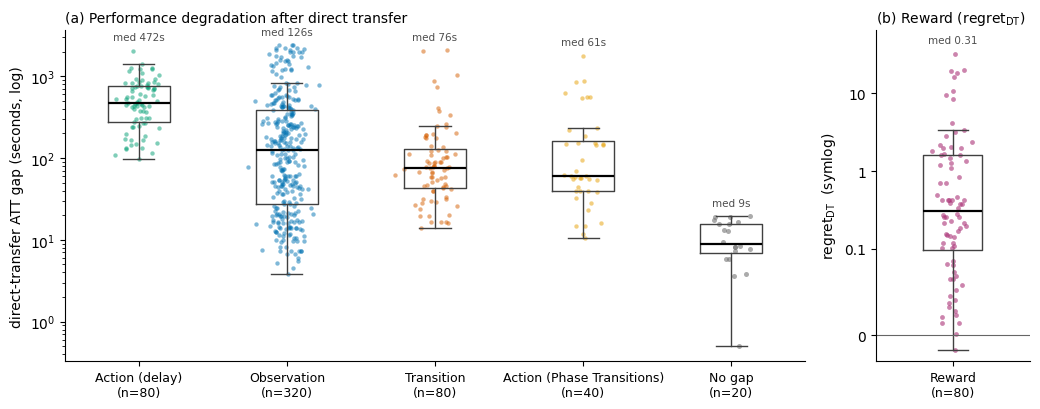

In [2]:
# Fig 1 — anatomy of the gap (RQ1): direct-transfer degradation per MDP component.
# Left: absolute ATT gap distributions (seconds, log scale), engine-floor band for reference.
# Right: pooled DT reward regret (regret_DT = R_oracle - R_DT, the reward chapter's
# sim2real-gap proxy -- R_real is not computable in sim), same visual grammar as (a):
# one column per component, settings pooled, dot = one cell.
# Each dot = one deployment cell (controller x network x setting); boxes = median/IQR.
rng = np.random.default_rng(0)
fig, (ax, axr) = plt.subplots(1, 2, figsize=(10.5, 4.2), width_ratios=[3.6, 0.75])

axis_order = sorted(GAP_AXES, key=lambda a: -dt[dt.axis == a]['gap'].median())
for i, axis in enumerate(axis_order):
    vals = dt[dt.axis == axis]['gap'].clip(lower=0.5)
    jitter = rng.normal(i, 0.07, len(vals))
    ax.scatter(jitter, vals, s=10, alpha=0.5, color=AXIS_COLORS[axis], linewidths=0)
    ax.boxplot([vals], positions=[i], widths=0.42, showfliers=False,
               medianprops=dict(color='black', linewidth=1.6),
               boxprops=dict(color='0.25'), whiskerprops=dict(color='0.25'),
               capprops=dict(color='0.25'))
    ax.text(i, vals.max() * 1.35, f'med {vals.median():.0f}s', fontsize=7.5,
            ha='center', color='0.3')

# engine-only transfer as its own column (same grammar): unperturbed SUMO eval
# vs CF baseline, one dot per controller x network. Not a hard per-cell floor.
i_eng = len(axis_order)
floor = engine['engine_gap'].clip(lower=0.5)
ax.scatter(rng.normal(i_eng, 0.07, len(floor)), floor, s=13, alpha=0.6,
           color='0.45', linewidths=0)
ax.boxplot([floor], positions=[i_eng], widths=0.42, showfliers=False,
           medianprops=dict(color='black', linewidth=1.6),
           boxprops=dict(color='0.25'), whiskerprops=dict(color='0.25'),
           capprops=dict(color='0.25'))
ax.text(i_eng, floor.max() * 1.35, f'med {floor.median():.0f}s', fontsize=7.5,
        ha='center', color='0.3')
ax.set_yscale('log')
ax.set_xticks(range(len(GAP_AXES) + 1))
ns = {a: (dt.axis == a).sum() for a in GAP_AXES}
ax.set_xticklabels([f'{AXIS_LABELS[a]}\n(n={ns[a]})' for a in axis_order]
                   + [f'No gap\n(n={len(floor)})'], fontsize=9)
ax.set_ylabel('direct-transfer ATT gap (seconds, log)')
ax.spines[['top', 'right']].set_visible(False)
ax.set_title('(a) Performance degradation after direct transfer', fontsize=10, loc='left')

# reward panel: settings POOLED into one column (mirrors panel a); the per-setting
# structure (inert on emission/safety, lift on fairness) lives in the RQ2 figure.
# regret_DT := R_oracle - R_DT (oracle = known-w* skyline). One cell is marginally
# negative (presslight/cologne3/fairness, -0.02): degenerate objective (zero fairness
# spread at DT), from-scratch oracle lands within training noise of the base policy.
r_dt = rewards[rewards.method == 'direct_transfer'].set_index(['agent', 'network', 'setting'])['R_real']
shortfall = (r_oracle - r_dt).reset_index(name='dR')
vals = shortfall['dR']
jitter = rng.normal(0, 0.06, len(vals))
axr.scatter(jitter, vals, s=12, alpha=0.6, color=AXIS_COLORS['reward'], linewidths=0)
axr.boxplot([vals], positions=[0], widths=0.42, showfliers=False,
            medianprops=dict(color='black', linewidth=1.6),
            boxprops=dict(color='0.25'), whiskerprops=dict(color='0.25'),
            capprops=dict(color='0.25'))
axr.axhline(0, color='0.4', linewidth=0.8)
axr.set_yscale('symlog', linthresh=0.1)
axr.set_yticks([0, 0.1, 1, 10])
axr.set_yticklabels(['0', '0.1', '1', '10'])
axr.set_ylim(min(-0.03, vals.min() * 1.5), vals.max() * 2.0)
axr.text(0.5, 0.985, f'med {vals.median():.2f}', fontsize=7.5, ha='center',
         va='top', color='0.3', transform=axr.transAxes)
axr.set_xticks([0])
axr.set_xticklabels([f'Reward\n(n={len(vals)})'], fontsize=9)
axr.set_xlim(-0.55, 0.55)
axr.set_ylabel(r'$\mathrm{regret}_{\mathrm{DT}}$  (symlog)')
axr.spines[['top', 'right']].set_visible(False)
axr.set_title(r'(b) Reward ($\mathrm{regret}_{\mathrm{DT}}$)', fontsize=10, loc='left')

fig.tight_layout()
save(fig, 'fig1_anatomy')
plt.show()

## Fig 2 — What mitigation recovers (RQ2)

saved figures/fig2_recovery


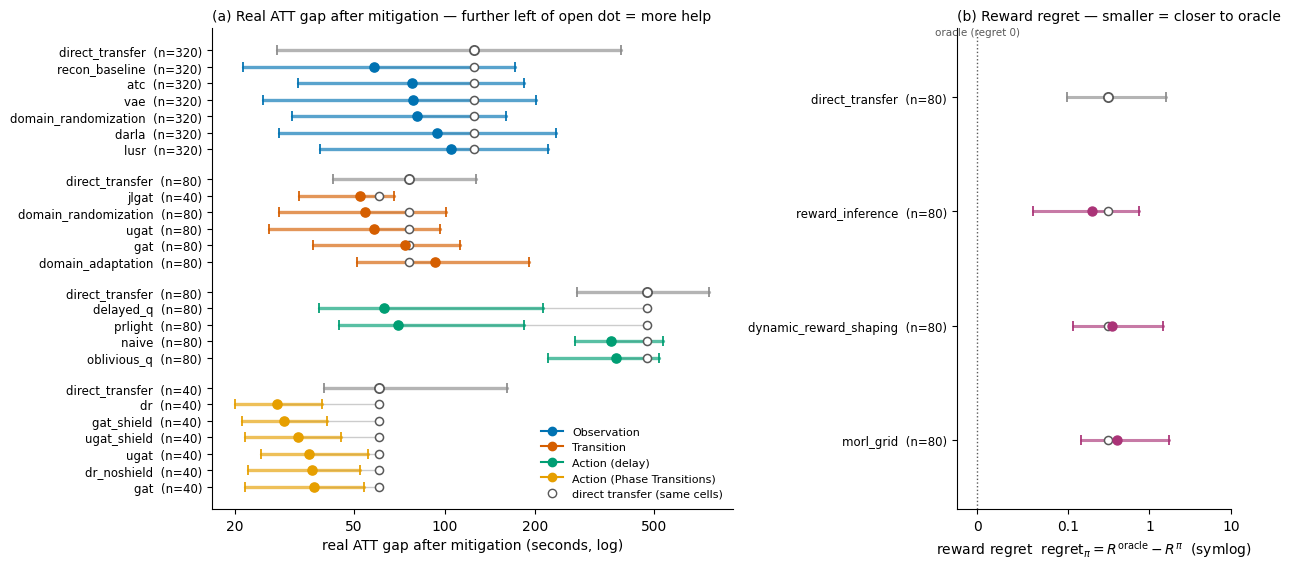

In [3]:
# Fig 2 — recovery forest (RQ2) in ABSOLUTE seconds: where each method's real gap
# lands vs direct transfer on the SAME cells. No recovery ratio -> no small-denominator
# filter, no clip: harm shows as the colored dot landing right of its DT marker.
# Row: colored dot+IQR = method's per-cell gap; open grey dot = DT median on the same
# cells; thin connector = the median shift. Engine floor band = pooled IQR (seconds).
dtg = dt.set_index(['axis', 'agent', 'network', 'setting'])['gap']
meth = gaps[gaps.method != 'direct_transfer'].copy()
meth['gap_dt'] = dtg.reindex(pd.MultiIndex.from_frame(meth[['axis', 'agent', 'network', 'setting']])).values

FLOOR_LO = 0.6  # balog-axis clip for display only
rows = []
for axis in GAP_AXES:
    sub = meth[meth.axis == axis]
    med = sub.groupby('method', observed=True)['gap'].median().sort_values()
    for m in med.index:
        r = sub[sub.method == m]
        rows.append({'axis': axis, 'method': m, 'n': len(r),
                     'med': r['gap'].median(), 'q1': r['gap'].quantile(0.25),
                     'q3': r['gap'].quantile(0.75), 'dt_med': r['gap_dt'].median()})
forest = pd.DataFrame(rows)

# landscape layout for a full-width (figure*) paper slot, ~2.2:1
fig, (ax, axr) = plt.subplots(1, 2, figsize=(12.6, 5.8), width_ratios=[1.9, 1])
y = 0
yticks, ylabels = [], []
for axis in GAP_AXES:
    # reference row: direct transfer's own distribution over all cells of this axis
    dsub = dt[dt.axis == axis]['gap']
    ax.plot([dsub.quantile(0.25), dsub.quantile(0.75)], [y, y], color='0.55',
            linewidth=2.4, alpha=0.65, solid_capstyle='round', zorder=2)
    ax.scatter([dsub.quantile(0.25), dsub.quantile(0.75)], [y, y], marker='|', s=46,
               color='0.55', alpha=0.9, linewidths=1.4, zorder=2)
    ax.scatter([dsub.median()], [y], facecolors='white', edgecolors='0.35',
               linewidths=1.3, s=44, zorder=4)
    yticks.append(y)
    ylabels.append(f'direct_transfer  (n={len(dsub)})')
    y -= 1
    block = forest[forest.axis == axis]
    for _, r in block.iterrows():
        color = AXIS_COLORS[axis]
        ax.plot([max(r.med, FLOOR_LO), r.dt_med], [y, y], color='0.8', linewidth=1.0,
                zorder=1)
        ax.plot([max(r.q1, FLOOR_LO), r.q3], [y, y], color=color, linewidth=2.4,
                alpha=0.65, solid_capstyle='round', zorder=2)
        ax.scatter([max(r.q1, FLOOR_LO), r.q3], [y, y], marker='|', s=46,
                   color=color, alpha=0.9, linewidths=1.4, zorder=2)
        ax.scatter([r.dt_med], [y], facecolors='white', edgecolors='0.35',
                   linewidths=1.1, s=34, zorder=3)
        ax.scatter([max(r.med, FLOOR_LO)], [y], color=color, s=44, zorder=4)
        yticks.append(y)
        ylabels.append(f'{r.method}  (n={r.n})')
        y -= 1
    y -= 0.8  # gap between axis groups
ax.set_xscale('log')
ax.set_xticks([20, 50, 100, 200, 500])
ax.set_xticklabels(['20', '50', '100', '200', '500'])
ax.minorticks_off()
ax.set_yticks(yticks)
ax.set_yticklabels(ylabels, fontsize=8.5)
ax.set_xlabel('real ATT gap after mitigation (seconds, log)')
ax.spines[['top', 'right']].set_visible(False)
handles = ([plt.Line2D([], [], color=AXIS_COLORS[a], marker='o', linestyle='-',
                       label=AXIS_LABELS[a]) for a in GAP_AXES]
           + [plt.Line2D([], [], marker='o', markerfacecolor='white',
                         markeredgecolor='0.35', linestyle='', label='direct transfer (same cells)')])
ax.legend(handles=handles, loc='lower right', fontsize=8, frameon=False)
ax.set_title('(a) Real ATT gap after mitigation — further left of open dot = more help',
             fontsize=10, loc='left')

# rewards, same reading direction AND grammar as (a): remaining R_real shortfall vs
# the ORACLE (known-w* skyline) in each cell -> smaller/left = better. The oracle is
# the reference point (x = 0 by definition), NOT a row; rows = DT + budgeted methods,
# each with the open DT dot (same 80 cells) + thin connector, exactly as in (a).
rw = rewards.copy()
rw['short'] = (r_oracle.reindex(pd.MultiIndex.from_frame(rw[['agent', 'network', 'setting']])).values
               - rw['R_real'])
dt_short = rw[rw.method == 'direct_transfer']['short']
axr.plot([dt_short.quantile(0.25), dt_short.quantile(0.75)], [0, 0], color='0.55',
         linewidth=2.2, alpha=0.65, solid_capstyle='round')
axr.scatter([dt_short.quantile(0.25), dt_short.quantile(0.75)], [0, 0], marker='|',
            s=46, color='0.55', alpha=0.9, linewidths=1.4)
axr.scatter([dt_short.median()], [0], facecolors='white', edgecolors='0.35',
            linewidths=1.3, s=44, zorder=3)
rm = rw[rw.method != 'direct_transfer']
med = rm.groupby('method')['short'].median().sort_values()
for i, m in enumerate(med.index, start=1):
    r = rm[rm.method == m]['short']
    axr.plot([r.median(), dt_short.median()], [-i, -i], color='0.8', linewidth=1.0,
             zorder=1)
    axr.plot([r.quantile(0.25), r.quantile(0.75)], [-i, -i], color=AXIS_COLORS['reward'],
             linewidth=2.2, alpha=0.65, solid_capstyle='round', zorder=2)
    axr.scatter([r.quantile(0.25), r.quantile(0.75)], [-i, -i], marker='|', s=46,
                color=AXIS_COLORS['reward'], alpha=0.9, linewidths=1.4, zorder=2)
    axr.scatter([dt_short.median()], [-i], facecolors='white', edgecolors='0.35',
                linewidths=1.1, s=34, zorder=3)
    axr.scatter([r.median()], [-i], color=AXIS_COLORS['reward'], s=42, zorder=4)
axr.axvline(0, color='0.35', linewidth=1.0, linestyle=':', zorder=1)
axr.text(0, 0.52, 'oracle (regret 0)', fontsize=7.5, ha='center', va='bottom', color='0.35')
axr.set_xscale('symlog', linthresh=0.1)
axr.set_xticks([0, 0.1, 1, 10])
axr.set_xticklabels(['0', '0.1', '1', '10'])
axr.minorticks_off()
axr.set_yticks([0] + [-i for i in range(1, len(med) + 1)])
axr.set_yticklabels([f'direct_transfer  (n={len(dt_short)})']
                    + [f'{m}  (n={len(rm[rm.method == m])})' for m in med.index],
                    fontsize=8.5)
axr.set_ylim(-len(med) - 0.6, 0.6)
axr.set_xlabel(r'reward regret  $\mathrm{regret}_{\pi} = R^{\mathrm{oracle}} - R^{\pi}$  (symlog)')
axr.spines[['top', 'right']].set_visible(False)
axr.set_title('(b) Reward regret — smaller = closer to oracle', fontsize=10, loc='left')

fig.tight_layout()
save(fig, 'fig2_recovery')
plt.show()

## Fig 3 — Where gaps live (RQ3)

saved figures/fig3_networks


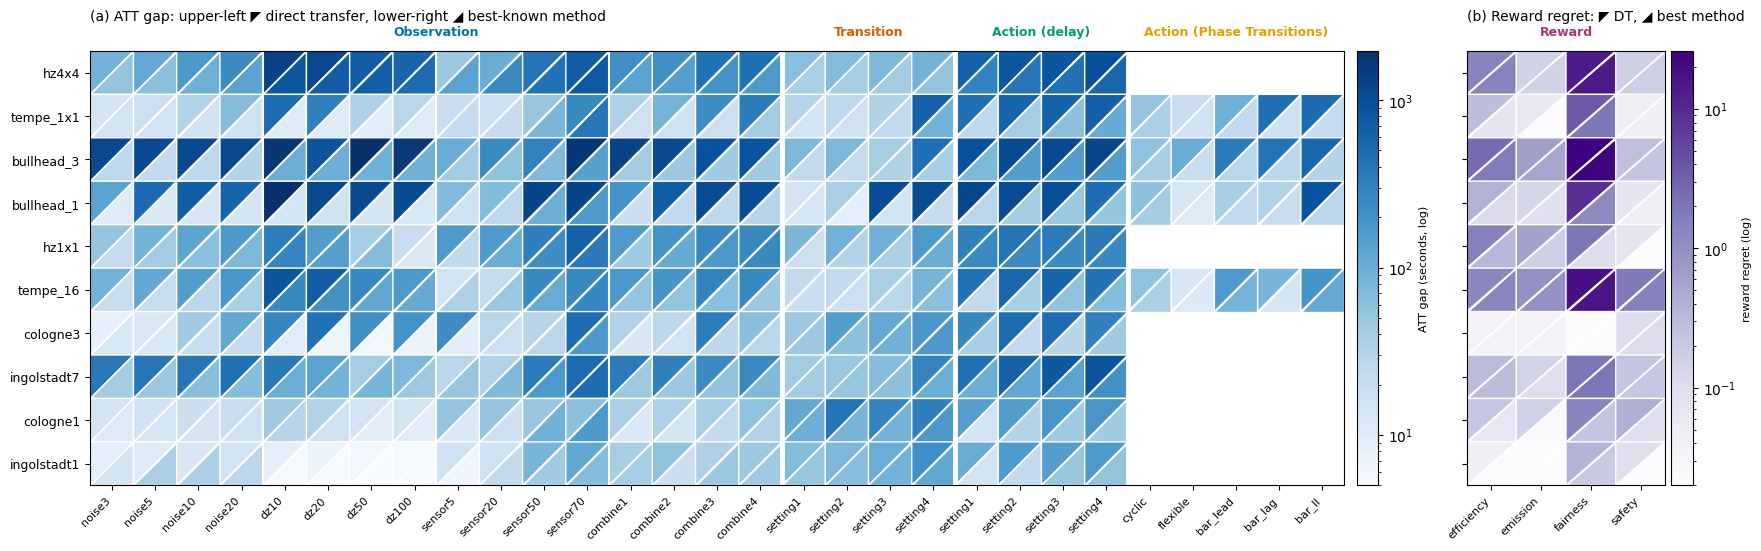

In [4]:
# Fig 3 — where gaps live and where they survive (RQ3). Split-cell heatmap:
# each cell = network x perturbation; UPPER-LEFT triangle = median DT gap,
# LOWER-RIGHT = gap remaining under the per-cell BEST-KNOWN method, SHARED
# Blues log scale so the two triangles are directly comparable. Right block:
# reward gap in its own currency, SAME triangle convention, anchored to the
# ORACLE (known-w* skyline): upper-left = R_oracle - R_DT (recoverable at zero
# adaptation), lower-right = R_oracle - best budgeted method (what survives the
# best mitigation). Rows ordered by CF baseline ATT (saturation proxy).
# No pooling across axes anywhere.
from matplotlib.colors import LogNorm
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.cm import ScalarMappable

d3 = dt.copy()
d3['sev'] = d3['setting'].astype(str)

best = (gaps[gaps.method != 'direct_transfer']
        .groupby(['axis', 'agent', 'network', 'setting'], observed=True)['gap']
        .min().reset_index())
best['sev'] = best['setting'].astype(str)

# ALL settings listed -- no severity aggregation anywhere (cell median = over the
# 2 controllers only, uniformly). Obs ordered family-by-family, mild -> severe.
OBS_SETTINGS = ['noise3', 'noise5', 'noise10', 'noise20',
                'dz10', 'dz20', 'dz50', 'dz100',
                'sensor5', 'sensor20', 'sensor50', 'sensor70',
                'combine1', 'combine2', 'combine3', 'combine4']
col_order = ([('observation', s) for s in OBS_SETTINGS]
             + [('transition', f'setting{i}') for i in range(1, 5)]
             + [('action_delay', f'setting{i}') for i in range(1, 5)]
             + [('action_pt', s) for s in ['cyclic', 'flexible', 'barrier_leading_fixed',
                                           'barrier_lagging_fixed', 'barrier_leading_lagging_fixed']])

net_order = list(dt.groupby('network')['cf_att'].median().sort_values(ascending=False).index)
grid = np.full((len(net_order), len(col_order)), np.nan)
grid_best = np.full_like(grid, np.nan)
for j, (axis, sev) in enumerate(col_order):
    sub = d3[(d3.axis == axis) & (d3.sev == sev)]
    med = sub.groupby('network', observed=True)['gap'].median()
    bsub = best[(best.axis == axis) & (best.sev == sev)]
    bmed = bsub.groupby('network', observed=True)['gap'].median()
    for i, net in enumerate(net_order):
        if net in med.index:
            grid[i, j] = max(med[net], 1.0)
        if net in bmed.index:
            grid_best[i, j] = max(bmed[net], 1.0)

# reward block: per cell, upper-left = R_oracle - R_DT; lower-right =
# NOTE R_real sums over intersections (global norms, no per-network calibration):
# color is comparable within a cell/row-pair, ordinal-only across networks --
# caption must not rank networks by raw shortfall (see analyze_rewards caveat 8).
# R_oracle - max over budgeted methods (>0 where even the best method trails the
# skyline; floored at 0.02 for the log scale, incl. the 3 cells where a method
# edged past the oracle by <=0.05).
r_dt = rewards[rewards.method == 'direct_transfer'].set_index(['agent', 'network', 'setting'])['R_real']
r_meth_best = rewards[rewards.method != 'direct_transfer'].groupby(['agent', 'network', 'setting'])['R_real'].max()
r_short = (r_oracle - r_dt).reset_index(name='short')
# label-aligned, NOT .values: (r_oracle - r_dt) keeps CSV row order while the
# groupby result is index-sorted -- positional assignment scrambles cells
r_short['short_best'] = (r_oracle - r_meth_best).reindex(
    pd.MultiIndex.from_frame(r_short[['agent', 'network', 'setting']])).values
RSET = ['efficiency_aligned', 'emission_heavy', 'fairness_heavy', 'physical_safety_heavy']
RLAB = ['efficiency', 'emission', 'fairness', 'safety']
rgrid = np.full((len(net_order), len(RSET)), np.nan)
rgrid_best = np.full_like(rgrid, np.nan)
for j, rs in enumerate(RSET):
    sub = r_short[r_short.setting == rs]
    med = sub.groupby('network')['short'].median()
    bmed = sub.groupby('network')['short_best'].median()
    for i, net in enumerate(net_order):
        if net in med.index:
            rgrid[i, j] = max(med[net], 0.02)
            rgrid_best[i, j] = max(bmed[net], 0.02)

fig, (ax, axr) = plt.subplots(1, 2, figsize=(17.5, 5.4), width_ratios=[29, 4.6],
                              sharey=True, constrained_layout=True)
norm = LogNorm(vmin=5, vmax=np.nanmax(grid))
cmap = plt.cm.Blues
for i in range(len(net_order)):
    for j in range(len(col_order)):
        if np.isnan(grid[i, j]):
            continue
        ul = [(j - 0.5, i - 0.5), (j + 0.5, i - 0.5), (j - 0.5, i + 0.5)]
        lr = [(j + 0.5, i - 0.5), (j + 0.5, i + 0.5), (j - 0.5, i + 0.5)]
        ax.add_patch(MplPolygon(ul, facecolor=cmap(norm(grid[i, j])),
                                edgecolor='white', linewidth=1.0))
        ax.add_patch(MplPolygon(lr, facecolor=cmap(norm(grid_best[i, j])),
                                edgecolor='white', linewidth=1.0))
ax.set_xlim(-0.5, len(col_order) - 0.5)
ax.set_ylim(len(net_order) - 0.5, -0.5)
for b in [16, 20, 24]:
    ax.axvline(b - 0.5, color='white', linewidth=3.5)
for b in [4, 8, 12]:
    ax.axvline(b - 0.5, color='white', linewidth=1.5)
ax.set_yticks(range(len(net_order)))
ax.set_yticklabels(net_order, fontsize=9)
short = {'barrier_leading_fixed': 'bar_lead', 'barrier_lagging_fixed': 'bar_lag',
         'barrier_leading_lagging_fixed': 'bar_ll'}
ax.set_xticks(range(len(col_order)))
ax.set_xticklabels([short.get(sv, sv) for _, sv in col_order], fontsize=8,
                   rotation=45, ha='right')
for (start, end, axis) in [(0, 16, 'observation'), (16, 20, 'transition'),
                           (20, 24, 'action_delay'), (24, 29, 'action_pt')]:
    ax.text((start + end - 1) / 2, -0.85, AXIS_LABELS[axis], ha='center', fontsize=9,
            color=AXIS_COLORS[axis], fontweight='bold')
ax.set_title('(a) ATT gap: upper-left \u25e4 direct transfer, lower-right \u25e2 best-known method',
             fontsize=10, loc='left', pad=22)

rnorm = LogNorm(vmin=0.02, vmax=max(np.nanmax(rgrid), 1.0))
rcmap = plt.cm.Purples
for i in range(len(net_order)):
    for j in range(len(RSET)):
        if np.isnan(rgrid[i, j]):
            continue
        ul = [(j - 0.5, i - 0.5), (j + 0.5, i - 0.5), (j - 0.5, i + 0.5)]
        lr = [(j + 0.5, i - 0.5), (j + 0.5, i + 0.5), (j - 0.5, i + 0.5)]
        axr.add_patch(MplPolygon(ul, facecolor=rcmap(rnorm(rgrid[i, j])),
                                 edgecolor='white', linewidth=1.0))
        axr.add_patch(MplPolygon(lr, facecolor=rcmap(rnorm(rgrid_best[i, j])),
                                 edgecolor='white', linewidth=1.0))
axr.set_xlim(-0.5, len(RSET) - 0.5)
axr.set_xticks(range(len(RSET)))
axr.set_xticklabels(RLAB, fontsize=8, rotation=45, ha='right')
axr.set_title('(b) Reward regret: \u25e4 DT, \u25e2 best method', fontsize=10, loc='left', pad=22)
axr.text(1.5, -0.85, 'Reward', ha='center', fontsize=9,
         color=AXIS_COLORS['reward'], fontweight='bold')
cb = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=ax, pad=0.01, fraction=0.035)
cb.set_label('ATT gap (seconds, log)', fontsize=8)
cbr = fig.colorbar(ScalarMappable(norm=rnorm, cmap=rcmap), ax=axr, pad=0.03,
                   fraction=0.12)
cbr.set_label('reward regret (log)', fontsize=8)
save(fig, 'fig3_networks')
plt.show()

## Fig 4 — Consistency across controllers (RQ4)

saved figures/fig4_controllers


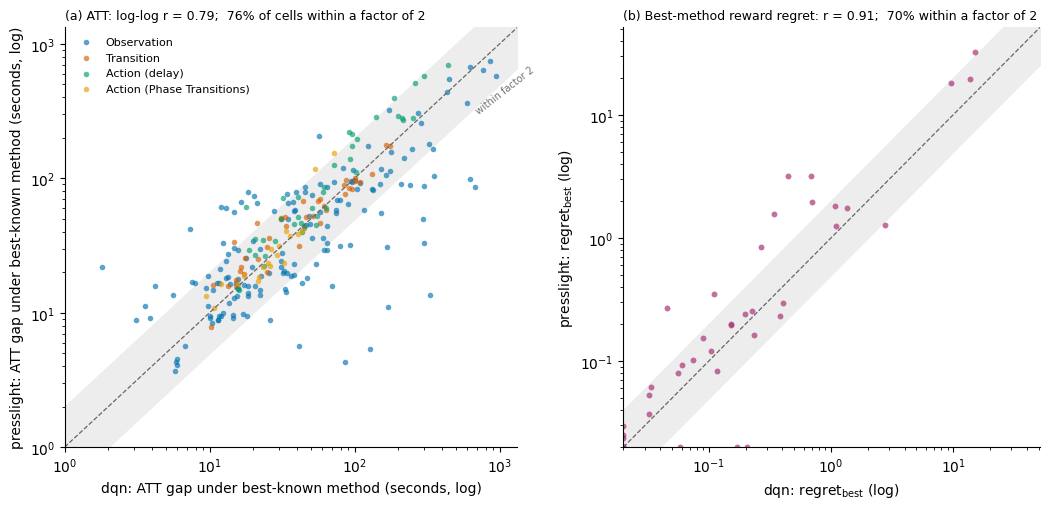

In [5]:
# Fig 4 — controller agreement (RQ4), AFTER mitigation: dqn vs presslight per
# (axis, network, setting) cell. Both panels are POST-mitigation so they ask the
# same question. (a) ATT gap under the per-cell BEST-KNOWN method (min over roster).
# (b) RESIDUAL reward gap under the best budgeted method (R_oracle - max_method R_real
# per cell) -- the reward analogue of (a): what even the best method leaves relative
# to the known-w* skyline. Bands = agreement within a factor of 2.
bestcell = (gaps[gaps.method != 'direct_transfer']
            .groupby(['axis', 'agent', 'network', 'setting'], observed=True)['gap']
            .min().reset_index())
piv = (bestcell.pivot_table(index=['axis', 'network', 'setting'], columns='agent',
                            values='gap', observed=True)
       .dropna()).clip(lower=1.0)

fig, (ax, axr) = plt.subplots(1, 2, figsize=(10.6, 5.2), width_ratios=[1, 0.92])
for axis in GAP_AXES:
    sub = piv.loc[axis]
    ax.scatter(sub['dqn'], sub['presslight'], s=16, alpha=0.65,
               color=AXIS_COLORS[axis], linewidths=0, label=AXIS_LABELS[axis])
lims = [1.0, max(piv.max()) * 1.4]
xs = np.array(lims)
ax.fill_between(xs, xs / 2, xs * 2, color='0.93', zorder=0)
ax.text(lims[1] * 0.5, lims[1] * 0.23, 'within factor 2', fontsize=7, color='0.45',
        rotation=38)
ax.plot(lims, lims, color='0.4', linewidth=0.9, linestyle='--', zorder=1)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('dqn: ATT gap under best-known method (seconds, log)')
ax.set_ylabel('presslight: ATT gap under best-known method (seconds, log)')
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=8, frameon=False, loc='upper left')
piv2 = piv.assign(dis=np.abs(np.log10(piv['dqn'] / piv['presslight'])))
corr = np.corrcoef(np.log10(piv['dqn']), np.log10(piv['presslight']))[0, 1]
within2 = (piv2['dis'] < np.log10(2)).mean()
ax.set_title(f'(a) ATT: log-log r = {corr:.2f};  {within2:.0%} of cells within a factor of 2',
             fontsize=9, loc='left')

# reward panel, POST-mitigation to match (a): residual R_real gap under the best
# budgeted method = R_oracle - max_method R_real per cell (label-aligned Series
# subtraction; both carry the (agent, network, setting) index). Floored at 0.02 for
# the log axis -- cells where the best method reaches the skyline pile at the corner
# (both controllers fully recover -> agree at the floor).
r_meth_best = (rewards[rewards.method != 'direct_transfer']
               .groupby(['agent', 'network', 'setting'])['R_real'].max())
rshort = (r_oracle - r_meth_best).reset_index(name='short')
rpiv = (rshort.pivot_table(index=['network', 'setting'], columns='agent',
                           values='short')
        .dropna()).clip(lower=0.02)
axr.scatter(rpiv['dqn'], rpiv['presslight'], s=18, alpha=0.7,
            color=AXIS_COLORS['reward'], linewidths=0)
rlims = [0.02, max(rpiv.max().max(), 1.0) * 1.6]
rxs = np.array(rlims)
axr.fill_between(rxs, rxs / 2, rxs * 2, color='0.93', zorder=0)
axr.plot(rlims, rlims, color='0.4', linewidth=0.9, linestyle='--', zorder=1)
axr.set_xscale('log'); axr.set_yscale('log')
axr.set_xlim(rlims); axr.set_ylim(rlims)
axr.set_xlabel(r'dqn: $\mathrm{regret}_{\mathrm{best}}$ (log)')
axr.set_ylabel(r'presslight: $\mathrm{regret}_{\mathrm{best}}$ (log)')
axr.spines[['top', 'right']].set_visible(False)
rw2 = np.abs(np.log10(rpiv['dqn'] / rpiv['presslight']))
rcorr = np.corrcoef(np.log10(rpiv['dqn']), np.log10(rpiv['presslight']))[0, 1]
rwithin = (rw2 < np.log10(2)).mean()
axr.set_title(f'(b) Best-method reward regret: r = {rcorr:.2f};  {rwithin:.0%} within a factor of 2',
              fontsize=9, loc='left')
fig.tight_layout()
save(fig, 'fig4_controllers')
plt.show()

## Fig 5 — Compound corruption vs additive null (RQ1)

saved figures/fig5_additivity


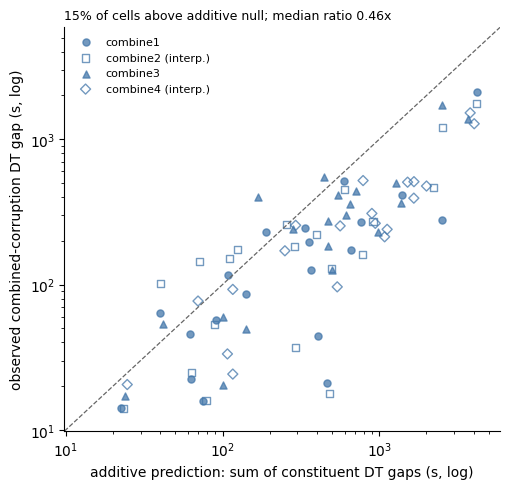

In [6]:
# Fig 5 — compound corruption vs additive null (RQ1 observation, Colosseum-style).
# Observed DT gap on combineN vs the SUM of its constituent single-corruption DT gaps.
# combine1/3 have exact single matches; combine2/4 interpolate the sensor gap over
# dropout probability (sensor settings = p 0.05/0.2/0.5/0.7).
SENSOR_P = {'sensor5': 0.05, 'sensor20': 0.2, 'sensor50': 0.5, 'sensor70': 0.7}
COMBINES = {  # combine -> (noise setting, dz setting, sensor dropout p)
    'combine1': ('noise3', 'dz100', 0.05),
    'combine2': ('noise3', 'dz50', 0.10),
    'combine3': ('noise3', 'dz20', 0.20),
    'combine4': ('noise5', 'dz10', 0.25),
}
EXACT = {'combine1', 'combine3'}

obs_dt = dt[dt.axis == 'observation'].set_index(['agent', 'network', 'setting'])['gap']
pts = []
for (agent, network), _ in obs_dt.groupby(level=[0, 1]):
    sensor_gaps = [obs_dt.get((agent, network, s), np.nan) for s in SENSOR_P]
    for comb, (noise_s, dz_s, p) in COMBINES.items():
        pred = (obs_dt.get((agent, network, noise_s), np.nan)
                + obs_dt.get((agent, network, dz_s), np.nan)
                + np.interp(p, list(SENSOR_P.values()), sensor_gaps))
        obs_gap = obs_dt.get((agent, network, comb), np.nan)
        if np.isfinite(pred) and np.isfinite(obs_gap):
            pts.append({'agent': agent, 'network': network, 'combine': comb,
                        'pred': max(pred, 1), 'obs': max(obs_gap, 1)})
add_df = pd.DataFrame(pts)

fig, ax = plt.subplots(figsize=(5.2, 5))
markers = {'combine1': 'o', 'combine2': 's', 'combine3': '^', 'combine4': 'D'}
for comb, m in markers.items():
    sub = add_df[add_df['combine'] == comb]
    ax.scatter(sub['pred'], sub['obs'], marker=m, s=26,
               facecolor='#4477AA' if comb in EXACT else 'none',
               edgecolor='#4477AA', linewidths=1.0, alpha=0.75,
               label=f"{comb}{'' if comb in EXACT else ' (interp.)'}")
lims = [add_df[['pred', 'obs']].min().min() * 0.7, add_df[['pred', 'obs']].max().max() * 1.4]
ax.plot(lims, lims, color='0.4', linewidth=0.9, linestyle='--')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('additive prediction: sum of constituent DT gaps (s, log)')
ax.set_ylabel('observed combined-corruption DT gap (s, log)')
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=8, frameon=False, loc='upper left')
frac = (add_df['obs'] > add_df['pred']).mean()
ratio = (add_df['obs'] / add_df['pred']).median()
ax.set_title(f'{frac:.0%} of cells above additive null; median ratio {ratio:.2f}x',
             fontsize=9, loc='left')
fig.tight_layout()
save(fig, 'fig5_additivity')
plt.show()

## Fig 6 — Reward gap as a trade-off (reward subsection)

saved figures/fig6_reward_tradeoff


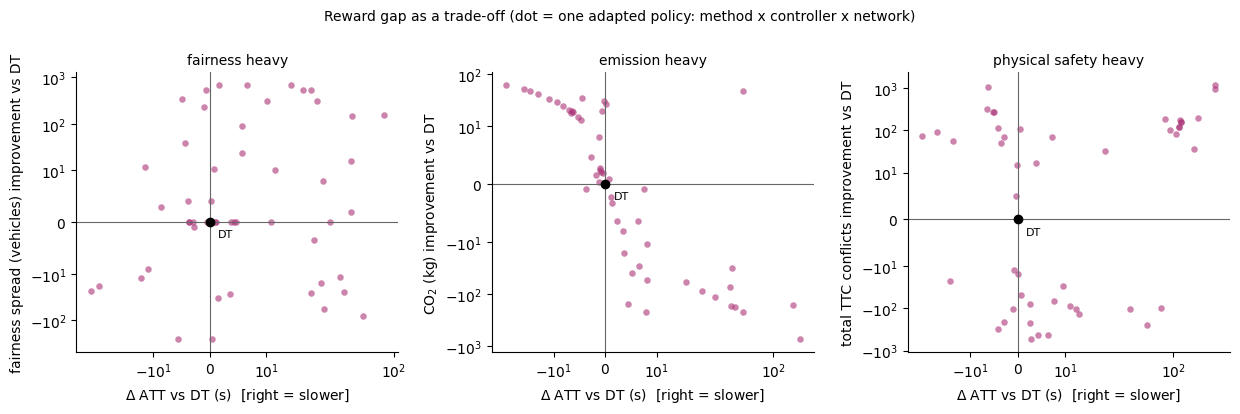

In [7]:
# Fig 6 — reward gap as a trade-off (reward subsection): per misaligned setting,
# what adapted policies buy with travel time. x = ATT paid vs DT (s); y = hidden
# metric improved vs DT, in the metric's OWN physical units (raw phi, before the
# hidden reward's norms/weights). Dot = one adapted policy (method x controller x
# network, pooled). symlog axes: linear within +-20s / +-10, log beyond.
# Three geometries: fairness = navigable frontier; emission = collinear with
# congestion (no independent axis); safety = no lever (noise swamps ATT changes).
REWARD_PANELS = [
    ('fairness_heavy', 'fairness', 'fairness spread (vehicles)'),
    ('emission_heavy', 'emission', r'CO$_2$ (kg)'),
    ('physical_safety_heavy', 'ssm_conflicts', 'total TTC conflicts'),
]
fig, axs = plt.subplots(1, 3, figsize=(12.5, 4.1))
for ax, (setting, col, name) in zip(axs, REWARD_PANELS):
    sub = rewards[rewards.setting == setting]
    base = sub[sub.method == 'direct_transfer'].set_index(['agent', 'network'])
    meth = sub[sub.method != 'direct_transfer'].set_index(['agent', 'network'])
    dx = meth['travel_time'] - base['travel_time'].reindex(meth.index)
    dy = base[col].reindex(meth.index) - meth[col]
    ax.scatter(dx, dy, s=22, alpha=0.6, color=AXIS_COLORS['reward'], linewidths=0)
    ax.axhline(0, color='0.4', lw=0.8)
    ax.axvline(0, color='0.4', lw=0.8)
    ax.plot(0, 0, marker='o', color='black', ms=6, zorder=5)
    ax.annotate('DT', (0, 0), textcoords='offset points', xytext=(6, -11), fontsize=8)
    ax.set_xscale('symlog', linthresh=20)
    ax.set_yscale('symlog', linthresh=10)
    ax.set_xlabel(r'$\Delta$ ATT vs DT (s)  [right = slower]')
    ax.set_ylabel(f'{name} improvement vs DT')
    ax.set_title(setting.replace('_', ' '), fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)
fig.suptitle('Reward gap as a trade-off (dot = one adapted policy: method x controller x network)',
             fontsize=10, y=1.0)
fig.tight_layout()
save(fig, 'fig6_reward_tradeoff')
plt.show()